In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv("f1_clean.csv")

FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
df = df.dropna(subset=FEATURES).reset_index(drop=True)

X = df[FEATURES].values
y = df['podium'].values

print(f"Dataset: {X.shape}")
print(f"Podium rate: {y.mean()*100:.1f}%")


Dataset: (5302, 4)
Podium rate: 17.1%


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}  Test: {X_test_s.shape}")
print(f"Same split as Steps 5 & 6 — fair comparison guaranteed")


Train: (4241, 4)  Test: (1061, 4)
Same split as Steps 5 & 6 — fair comparison guaranteed


In [3]:
print("Logistic Regression parameters:")
print("  C      : regularisation strength (we will tune this)")
print("  solver : optimisation algorithm ('lbfgs' is default and robust)")
print("  max_iter: maximum iterations for the solver to converge")
print()
print("Decision rule: predict podium if sigmoid(w^T x + b) > 0.5")


Logistic Regression parameters:
  C      : regularisation strength (we will tune this)
  solver : optimisation algorithm ('lbfgs' is default and robust)
  max_iter: maximum iterations for the solver to converge

Decision rule: predict podium if sigmoid(w^T x + b) > 0.5


In [4]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

lr = LogisticRegression(
    class_weight='balanced',  
    solver='lbfgs',           
    max_iter=1000,
    random_state=42
)

grid_lr = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_lr.fit(X_train_s, y_train)

print(f"Best C     : {grid_lr.best_params_['C']}")
print(f"Best CV AUC: {grid_lr.best_score_:.3f}")
print()
print("All C values tested:")
results = pd.DataFrame(grid_lr.cv_results_)
for _, row in results[['param_C','mean_test_score','std_test_score']].iterrows():
    bar = '█' * int(row['mean_test_score'] * 40)
    print(f"  C={str(row['param_C']):<8} AUC={row['mean_test_score']:.3f} ± {row['std_test_score']:.3f}  {bar}")


Best C     : 1
Best CV AUC: 1.000

All C values tested:
  C=0.001    AUC=0.996 ± 0.001  ███████████████████████████████████████
  C=0.01     AUC=0.998 ± 0.001  ███████████████████████████████████████
  C=0.1      AUC=1.000 ± 0.000  ███████████████████████████████████████
  C=1.0      AUC=1.000 ± 0.000  ███████████████████████████████████████
  C=10.0     AUC=1.000 ± 0.000  ███████████████████████████████████████
  C=100.0    AUC=1.000 ± 0.000  ███████████████████████████████████████
  C=1000.0   AUC=1.000 ± 0.000  ███████████████████████████████████████


In [5]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test_s)
y_prob_lr = best_lr.predict_proba(X_test_s)[:, 1]  # P(podium)

print(f"=== Logistic Regression (C={grid_lr.best_params_['C']}) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr)*100:.1f}%")
print(f"AUC Score : {roc_auc_score(y_test, y_prob_lr):.3f}")
print()
print(classification_report(y_test, y_pred_lr,
                             target_names=['No podium', 'Podium']))


=== Logistic Regression (C=1) ===
Accuracy  : 99.8%
AUC Score : 1.000

              precision    recall  f1-score   support

   No podium       1.00      1.00      1.00       879
      Podium       0.99      1.00      0.99       182

    accuracy                           1.00      1061
   macro avg       0.99      1.00      1.00      1061
weighted avg       1.00      1.00      1.00      1061



=== Feature Coefficients ===
(Positive = increases P(podium), Negative = decreases P(podium))

        Feature  Coefficient
         points    11.244430
           grid    -0.297432
fastestLapSpeed     0.041490
           laps     0.034079

Most important feature: points

Note: KNN and SVM CANNOT give you this — it is unique to linear models.
This interpretability is why Logistic Regression is still widely used.


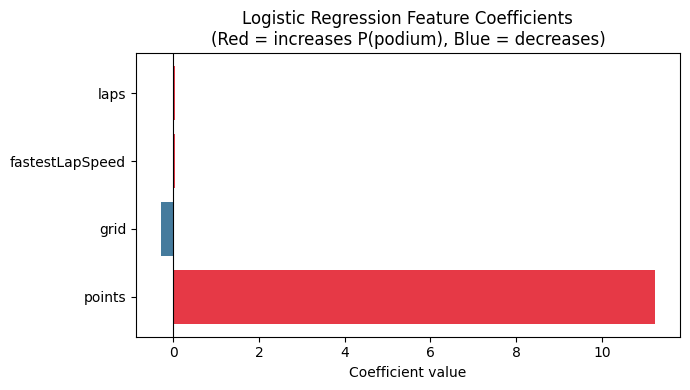

Saved: lr_coefficients.png


In [6]:
coefficients = best_lr.coef_[0]

coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': coefficients,
    'Abs value'  : np.abs(coefficients)
}).sort_values('Abs value', ascending=False)

print("=== Feature Coefficients ===")
print("(Positive = increases P(podium), Negative = decreases P(podium))")
print()
print(coef_df[['Feature','Coefficient']].to_string(index=False))
print()
print("Most important feature:", coef_df.iloc[0]['Feature'])
print()
print("Note: KNN and SVM CANNOT give you this — it is unique to linear models.")
print("This interpretability is why Logistic Regression is still widely used.")

# Plot coefficients
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#e63946' if c > 0 else '#457b9d' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("Coefficient value")
ax.set_title("Logistic Regression Feature Coefficients\n"
             "(Red = increases P(podium), Blue = decreases)")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lr_coefficients.png")


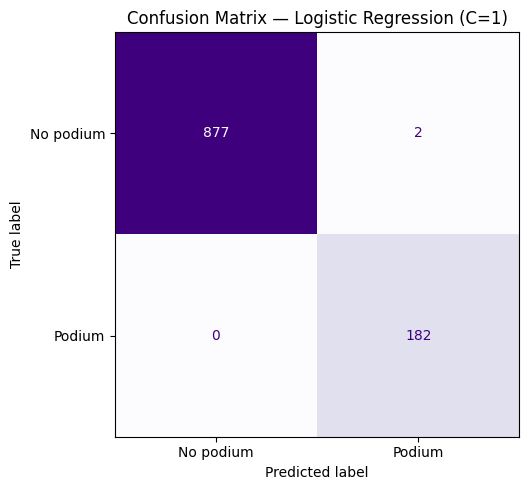

TN: 877  FP: 2  FN: 0  TP: 182


In [7]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_lr, display_labels=['No podium','Podium']
                       ).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title(f"Confusion Matrix — Logistic Regression (C={grid_lr.best_params_['C']})")
plt.tight_layout()
plt.savefig("lr_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"TN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")


In [8]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)

y_pred_lda = lda.predict(X_test_s)
y_prob_lda = lda.predict_proba(X_test_s)[:, 1]

print("=== Linear Discriminant Analysis ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lda)*100:.1f}%")
print(f"AUC Score : {roc_auc_score(y_test, y_prob_lda):.3f}")
print()
print(classification_report(y_test, y_pred_lda,
                             target_names=['No podium', 'Podium']))


=== Linear Discriminant Analysis ===
Accuracy  : 99.8%
AUC Score : 1.000

              precision    recall  f1-score   support

   No podium       1.00      1.00      1.00       879
      Podium       0.99      1.00      0.99       182

    accuracy                           1.00      1061
   macro avg       0.99      1.00      1.00      1061
weighted avg       1.00      1.00      1.00      1061



Loaded KNN probabilities from Step 5


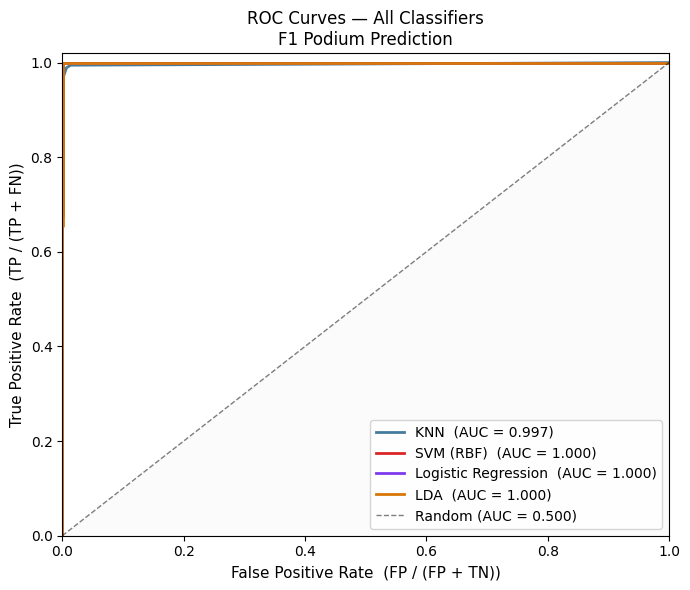

Saved: roc_all_models.png  ← upload this to Overleaf!


In [9]:
try:
    y_prob_knn = np.load("knn_y_prob.npy")
    y_test_loaded = np.load("y_test.npy")
    print("Loaded KNN probabilities from Step 5")
except FileNotFoundError:
    print("knn_y_prob.npy not found — re-running KNN quickly...")
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import cross_val_score as cvs
    best_k = 5  # fallback K
    knn_tmp = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
    knn_tmp.fit(X_train_s, y_train)
    y_prob_knn = knn_tmp.predict_proba(X_test_s)[:, 1]
    y_test_loaded = y_test
    np.save("knn_y_prob.npy", y_prob_knn)

y_prob_svm = np.load("svm_y_prob.npy")

models = {
    'KNN'                : (y_prob_knn,  '#457b9d'),
    'SVM (RBF)'          : (y_prob_svm,  '#DC2626'),
    'Logistic Regression': (y_prob_lr,   '#7C3AED'),
    'LDA'                : (y_prob_lda,  '#D97706'),
}

fig, ax = plt.subplots(figsize=(7, 6))

for name, (probs, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.fill_between([0,1],[0,1], alpha=0.03, color='gray')

ax.set_xlabel("False Positive Rate  (FP / (FP + TN))", fontsize=11)
ax.set_ylabel("True Positive Rate  (TP / (TP + FN))", fontsize=11)
ax.set_title("ROC Curves — All Classifiers\nF1 Podium Prediction", fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: roc_all_models.png  ← upload this to Overleaf!")


In [10]:
import os
if not os.path.exists("knn_y_prob.npy"):
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import cross_val_score

    print("knn_y_prob.npy not found — regenerating KNN probabilities...")
    cv_scores = []
    for k in range(1, 21):
        knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        scores = cross_val_score(knn_tmp, X_train_s, y_train,
                                 cv=5, scoring='roc_auc')
        cv_scores.append(scores.mean())

    best_k = list(range(1,21))[np.argmax(cv_scores)]
    knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
    knn_final.fit(X_train_s, y_train)
    y_prob_knn_saved = knn_final.predict_proba(X_test_s)[:, 1]
    np.save("knn_y_prob.npy", y_prob_knn_saved)
    print(f"Saved knn_y_prob.npy (K={best_k})")
else:
    print("knn_y_prob.npy already exists — nothing to do.")
    print("Run Cell 9 to generate roc_all_models.png")


knn_y_prob.npy already exists — nothing to do.
Run Cell 9 to generate roc_all_models.png


In [11]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

df = pd.read_csv("f1_clean.csv")
FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
df = df.dropna(subset=FEATURES).reset_index(drop=True)
X = df[FEATURES].values
y = df['podium'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

y_prob_knn = np.load("knn_y_prob.npy")
y_prob_svm = np.load("svm_y_prob.npy")

y_pred_knn = (y_prob_knn >= 0.5).astype(int)
y_pred_svm = (y_prob_svm >= 0.5).astype(int)

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV

grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', solver='lbfgs',
                       max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    cv=5, scoring='roc_auc', n_jobs=-1
)
grid_lr.fit(X_train_s, y_train)
best_lr = grid_lr.best_estimator_
y_pred_lr  = best_lr.predict(X_test_s)
y_prob_lr  = best_lr.predict_proba(X_test_s)[:, 1]

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)
y_pred_lda = lda.predict(X_test_s)
y_prob_lda = lda.predict_proba(X_test_s)[:, 1]

print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC':>8} {'F1 (podium)':>12}")
print("=" * 65)

all_models = [
    ("KNN",                 y_pred_knn, y_prob_knn),
    ("SVM (RBF)",           y_pred_svm, y_prob_svm),
    ("Logistic Regression", y_pred_lr,  y_prob_lr),
    ("LDA",                 y_pred_lda, y_prob_lda),
]

for name, preds, probs in all_models:
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    f1  = f1_score(y_test, preds, pos_label=1)
    print(f"{name:<25} {acc*100:>9.1f}%  {auc:>7.3f}  {f1:>11.3f}")

Model                       Accuracy      AUC  F1 (podium)
KNN                            99.3%    0.997        0.981
SVM (RBF)                      99.9%    1.000        0.997
Logistic Regression            99.8%    1.000        0.995
LDA                            99.8%    1.000        0.995
